# Regridding Comparison

Previously I regridded ORAS5 data to an ERA5 grid using ScipyGridData which, on a large scale, seemed to work well. The purpose of this notebook is to take a closer look at the differences between the regridded ORAS5 data and ERA5 data and determine to what extent this regrdding technique can be used.

The notebook is split into the following sections:

1. Regridding Method
2. Zoomed Visual Comparison
3. Histograms

## 1. Regridding Method

Below is the method of regridding used:

In [2]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from scipy.interpolate import griddata

In [3]:
file_paths = [
    r"C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ORAS5\SST_2022\sosstsst_control_monthly_highres_2D_202201_OPER_v0.1.nc",
    r"C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ORAS5\SST_2022\sosstsst_control_monthly_highres_2D_202202_OPER_v0.1.nc",
    r"C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ORAS5\SST_2022\sosstsst_control_monthly_highres_2D_202203_OPER_v0.1.nc",
    r"C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ORAS5\SST_2022\sosstsst_control_monthly_highres_2D_202204_OPER_v0.1.nc",
    r"C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ORAS5\SST_2022\sosstsst_control_monthly_highres_2D_202205_OPER_v0.1.nc",
    r"C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ORAS5\SST_2022\sosstsst_control_monthly_highres_2D_202206_OPER_v0.1.nc",
    r"C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ORAS5\SST_2022\sosstsst_control_monthly_highres_2D_202207_OPER_v0.1.nc",
    r"C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ORAS5\SST_2022\sosstsst_control_monthly_highres_2D_202208_OPER_v0.1.nc",
    r"C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ORAS5\SST_2022\sosstsst_control_monthly_highres_2D_202209_OPER_v0.1.nc",
    r"C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ORAS5\SST_2022\sosstsst_control_monthly_highres_2D_202210_OPER_v0.1.nc",
    r"C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ORAS5\SST_2022\sosstsst_control_monthly_highres_2D_202211_OPER_v0.1.nc",
    r"C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ORAS5\SST_2022\sosstsst_control_monthly_highres_2D_202212_OPER_v0.1.nc",
]

oras5_ds = xr.open_mfdataset(
    file_paths,
    combine="nested",
    concat_dim="time_counter"
)

print(oras5_ds)

<xarray.Dataset> Size: 82MB
Dimensions:            (time_counter: 12, y: 1021, x: 1442, bnds: 2)
Coordinates:
    nav_lat            (y, x) float32 6MB dask.array<chunksize=(1021, 1442), meta=np.ndarray>
    nav_lon            (y, x) float32 6MB dask.array<chunksize=(1021, 1442), meta=np.ndarray>
  * time_counter       (time_counter) datetime64[ns] 96B 2022-01-16T12:00:00 ...
Dimensions without coordinates: y, x, bnds
Data variables:
    sosstsst           (time_counter, y, x) float32 71MB dask.array<chunksize=(1, 1021, 1442), meta=np.ndarray>
    time_counter_bnds  (time_counter, bnds) datetime64[ns] 192B dask.array<chunksize=(1, 2), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.6
    NCO:          netCDF Operators version 4.9.6 (Homepage = http://nco.sf.ne...
    title:        Monthly mean 2D Sea Surface fields
    source:       ORAS5 - backward extension (ECMWF)
    institution:  European Centre for Medium-Range Weather Forecasts (ECMWF) ...
    reference:    https://www.ecmwf

In [4]:
sst = oras5_ds["sosstsst"]
nav_lat = oras5_ds["nav_lat"]
nav_lon = oras5_ds["nav_lon"]

sst_annual = sst.mean("time_counter")

In [5]:
file_path_b = r"C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\data_stream-moda_stepType-avgua.nc"

colour_map = "Spectral_r"

era5_ds = xr.open_dataset(file_path_b)

In [6]:
lat_t = era5_ds["latitude"].values
lon_t = era5_ds["longitude"].values

lon2, lat2 = np.meshgrid(lon_t, lat_t)

In [7]:
# Flattening ORAS5 grid
src_lon = nav_lon.values.ravel()
src_lat = nav_lat.values.ravel()
src_val = sst_annual.values.ravel()

# Removing nan vals
mask = np.isfinite(src_lon) & np.isfinite(src_lat) & np.isfinite(src_val)
points = np.column_stack([src_lon[mask], src_lat[mask]])
values = src_val[mask]

# Interpolating (chooses 3 nearest points to avg)
sst_era5 = griddata(
    points,
    values,
    (lon2, lat2),
    method="linear")

# Filling coast gaps with nearest neighbour
sst_era5_nn = griddata(points, values, (lon2, lat2), method="nearest")
sst_era5 = np.where(np.isfinite(sst_era5), sst_era5, sst_era5_nn)

In [8]:
# Turning oras5 sst into array and assigning era5 lat/lons
sst_era5_da = xr.DataArray(
    sst_era5,
    dims=("latitude", "longitude"),
    coords={
        "latitude": lat_t,
        "longitude": lon_t
    },
    name="sst_oras5_regridded")

sst_era5_da.attrs["description"] = "ORAS5 SST (2022 annual mean) regridded to ERA5 grid using scipy.griddata"

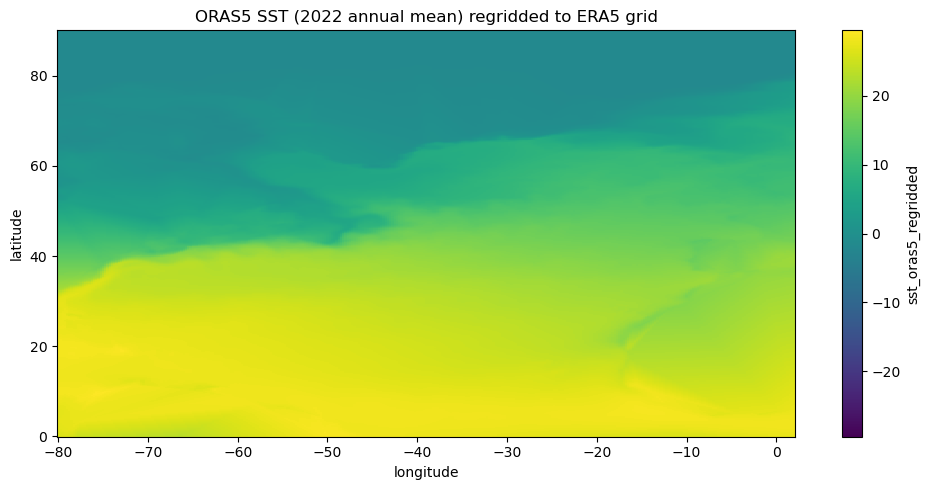

In [9]:
plt.figure(figsize=(10, 5))
sst_era5_da.plot(cmap="viridis")
plt.title("ORAS5 SST (2022 annual mean) regridded to ERA5 grid")
plt.tight_layout()
plt.show()

In [10]:
era5_sst = era5_ds["sst"]

# just taking first time step
era5_sst_2d = era5_sst.isel(valid_time=0)

# Creating oceanmask (false for nan values)
ocean_mask = np.isfinite(era5_sst_2d.values)

In [11]:
# applying mask to regridded oras5 data (nan values over land)
sst_oras5_masked = sst_era5_da.where(ocean_mask)

sst_oras5_masked.name = "sst_oras5_regridded_masked"
sst_oras5_masked.attrs["mask_note"] = "Masked using ERA5 SST NaN pattern (land = NaN)"

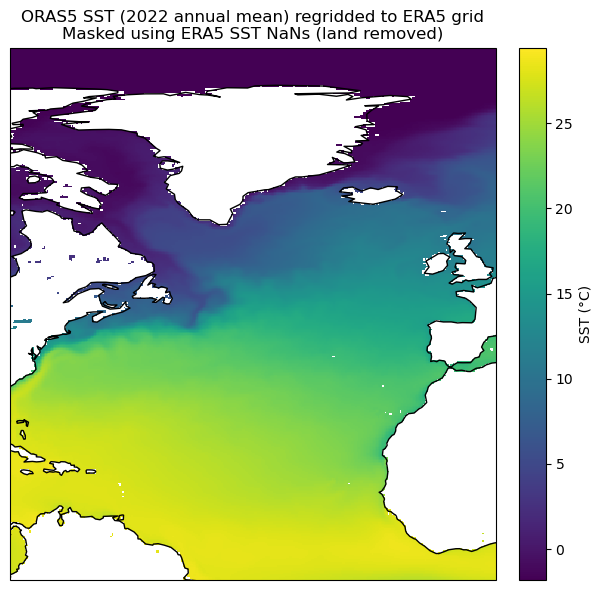

In [12]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

lon_t = sst_oras5_masked["longitude"].values
lat_t = sst_oras5_masked["latitude"].values

fig = plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines()

pm = ax.pcolormesh(
    lon_t, lat_t, sst_oras5_masked.values,
    shading="auto",
    transform=ccrs.PlateCarree(),
    cmap="viridis"
)

plt.colorbar(pm, orientation="vertical", pad=0.02, label="SST (°C)")
plt.title("ORAS5 SST (2022 annual mean) regridded to ERA5 grid\nMasked using ERA5 SST NaNs (land removed)")
plt.tight_layout()
plt.show()

## 2. Zoomed Visual Comparison

On a large scale (zoomed out) view the two datasets look almost identical:

In [13]:
# era5 in celcius
era5_sst = era5_ds["sst"] - 273.15

# Annual 2022 AVG
era5_sst_annual = era5_sst.mean("valid_time")

In [14]:
# Making sure only ocean values compared
vals = [sst_oras5_masked.values, era5_sst_annual.values]

vmin = float(np.nanmin(vals))
vmax = float(np.nanmax(vals))
print(f"Shared colour scale: vmin={vmin:.2f}, vmax={vmax:.2f}")

Shared colour scale: vmin=-1.81, vmax=30.78


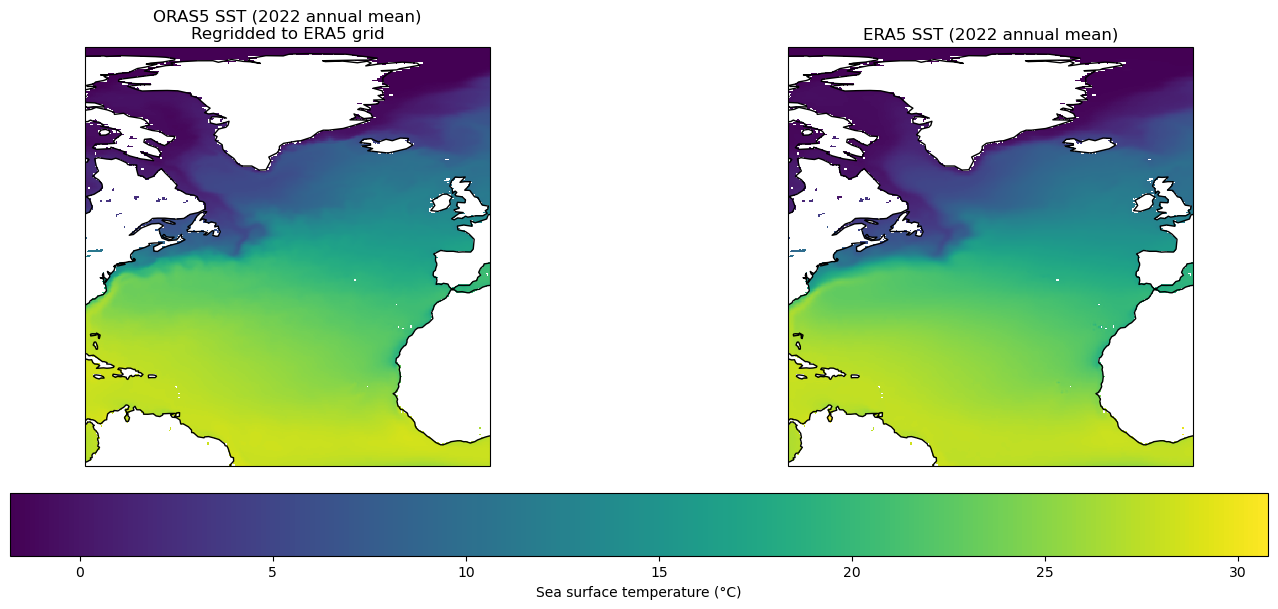

In [15]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

lon = sst_oras5_masked["longitude"].values
lat = sst_oras5_masked["latitude"].values

lon_min, lon_max = -80, 2
lat_min, lat_max = 0, 85

fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 6),
    subplot_kw={"projection": ccrs.PlateCarree()},
    constrained_layout=True
)

# regridded oras5
ax = axes[0]
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
ax.coastlines()

pm = ax.pcolormesh(
    lon, lat, sst_oras5_masked.values,
    shading="auto",
    transform=ccrs.PlateCarree(),
    cmap="viridis",
    vmin=vmin, vmax=vmax
)
ax.set_title("ORAS5 SST (2022 annual mean)\nRegridded to ERA5 grid")

# era5
ax = axes[1]
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
ax.coastlines()

ax.pcolormesh(
    lon, lat, era5_sst_annual.values,
    shading="auto",
    transform=ccrs.PlateCarree(),
    cmap="viridis",
    vmin=vmin, vmax=vmax
)
ax.set_title("ERA5 SST (2022 annual mean)")

# Shared colourbar
cbar = fig.colorbar(pm, ax=axes.ravel().tolist(), orientation="horizontal", pad=0.05)
cbar.set_label("Sea surface temperature (°C)")

plt.show()

As we zoom in on the UK the differences begin to become more apparent:

UK shared scale: vmin=7.78, vmax=14.83


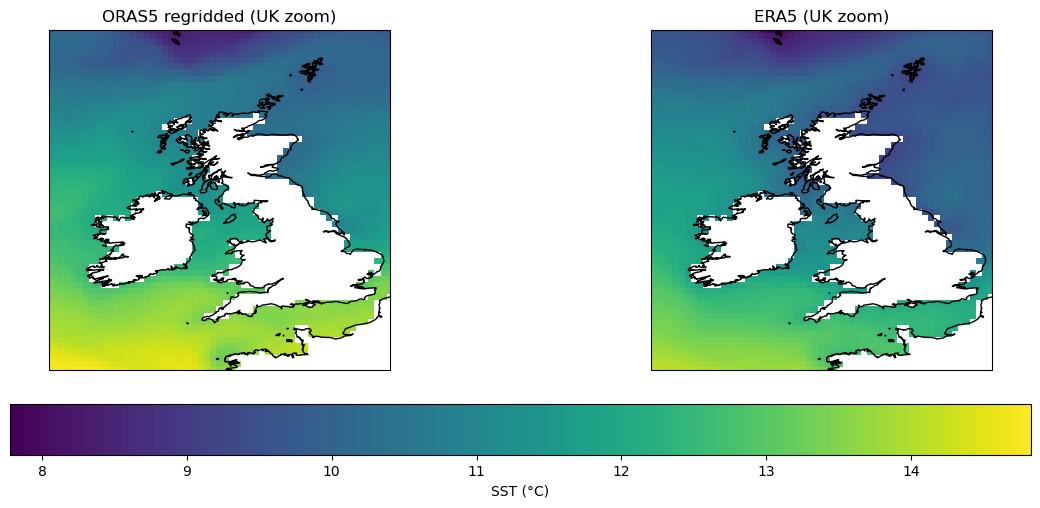

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# UK Box
UK = dict(lon_min=-12, lon_max=2, lat_min=48, lat_max=62)

# Only comparing where valid + ensuring lik-for-like comparison
oras, era = xr.align(sst_oras5_masked, era5_sst_annual, join="exact")
both_mask = np.isfinite(oras) & np.isfinite(era)

oras_uk = oras.where(both_mask).sel(longitude=slice(UK["lon_min"], UK["lon_max"]),
                                   latitude=slice(UK["lat_max"], UK["lat_min"]))
era_uk  = era.where(both_mask).sel(longitude=slice(UK["lon_min"], UK["lon_max"]),
                                  latitude=slice(UK["lat_max"], UK["lat_min"]))

vmin = float(np.nanmin([oras_uk.values, era_uk.values]))
vmax = float(np.nanmax([oras_uk.values, era_uk.values]))
print(f"UK shared scale: vmin={vmin:.2f}, vmax={vmax:.2f}")

proj = ccrs.PlateCarree()
fig, axes = plt.subplots(1, 2, figsize=(12, 5), subplot_kw={"projection": proj}, constrained_layout=True)

for ax, field, title in [
    (axes[0], oras_uk, "ORAS5 regridded (UK zoom)"),
    (axes[1], era_uk,  "ERA5 (UK zoom)"),
]:
    ax.set_extent([UK["lon_min"], UK["lon_max"], UK["lat_min"], UK["lat_max"]], crs=proj)
    ax.coastlines()
    pm = ax.pcolormesh(field.longitude, field.latitude, field.values,
                       shading="auto", transform=proj, vmin=vmin, vmax=vmax)
    ax.set_title(title)

cbar = fig.colorbar(pm, ax=axes, orientation="horizontal", pad=0.08)
cbar.set_label("SST (°C)")
plt.show()


UK shared scale: vmin=9.46, vmax=14.59


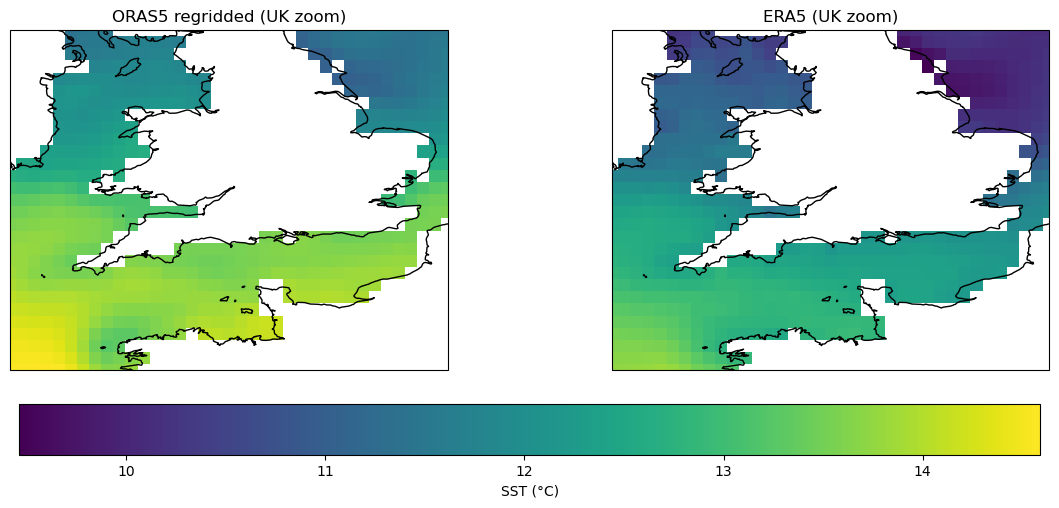

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# Smaller Box
UK = dict(lon_min=-7, lon_max=2, lat_min=48, lat_max=55)

# Only comparing where valid + ensuring lik-for-like comparison
oras, era = xr.align(sst_oras5_masked, era5_sst_annual, join="exact")
both_mask = np.isfinite(oras) & np.isfinite(era)

oras_uk = oras.where(both_mask).sel(longitude=slice(UK["lon_min"], UK["lon_max"]),
                                   latitude=slice(UK["lat_max"], UK["lat_min"]))
era_uk  = era.where(both_mask).sel(longitude=slice(UK["lon_min"], UK["lon_max"]),
                                  latitude=slice(UK["lat_max"], UK["lat_min"]))

vmin = float(np.nanmin([oras_uk.values, era_uk.values]))
vmax = float(np.nanmax([oras_uk.values, era_uk.values]))
print(f"UK shared scale: vmin={vmin:.2f}, vmax={vmax:.2f}")

proj = ccrs.PlateCarree()
fig, axes = plt.subplots(1, 2, figsize=(12, 5), subplot_kw={"projection": proj}, constrained_layout=True)

for ax, field, title in [
    (axes[0], oras_uk, "ORAS5 regridded (UK zoom)"),
    (axes[1], era_uk,  "ERA5 (UK zoom)"),
]:
    ax.set_extent([UK["lon_min"], UK["lon_max"], UK["lat_min"], UK["lat_max"]], crs=proj)
    ax.coastlines()
    pm = ax.pcolormesh(field.longitude, field.latitude, field.values,
                       shading="auto", transform=proj, vmin=vmin, vmax=vmax)
    ax.set_title(title)

cbar = fig.colorbar(pm, ax=axes, orientation="horizontal", pad=0.08)
cbar.set_label("SST (°C)")
plt.show()


UK shared scale: vmin=11.32, vmax=14.29


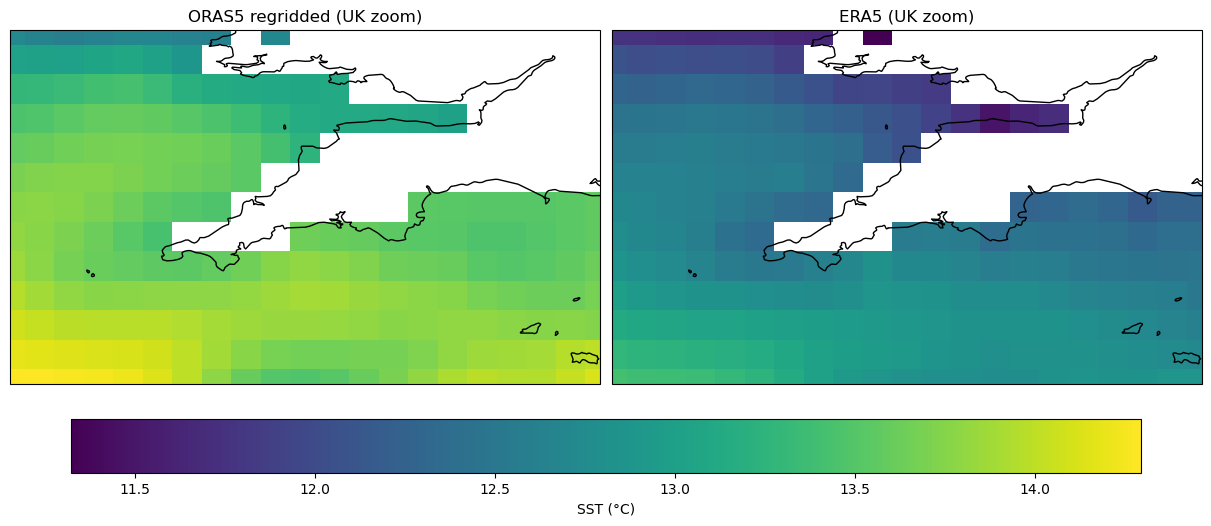

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# Smaller Box
UK = dict(lon_min=-7, lon_max=-2, lat_min=49, lat_max=52)

# Only comparing where valid + ensuring lik-for-like comparison
oras, era = xr.align(sst_oras5_masked, era5_sst_annual, join="exact")
both_mask = np.isfinite(oras) & np.isfinite(era)

oras_uk = oras.where(both_mask).sel(longitude=slice(UK["lon_min"], UK["lon_max"]),
                                   latitude=slice(UK["lat_max"], UK["lat_min"]))
era_uk  = era.where(both_mask).sel(longitude=slice(UK["lon_min"], UK["lon_max"]),
                                  latitude=slice(UK["lat_max"], UK["lat_min"]))

vmin = float(np.nanmin([oras_uk.values, era_uk.values]))
vmax = float(np.nanmax([oras_uk.values, era_uk.values]))
print(f"UK shared scale: vmin={vmin:.2f}, vmax={vmax:.2f}")

proj = ccrs.PlateCarree()
fig, axes = plt.subplots(1, 2, figsize=(12, 5), subplot_kw={"projection": proj}, constrained_layout=True)

for ax, field, title in [
    (axes[0], oras_uk, "ORAS5 regridded (UK zoom)"),
    (axes[1], era_uk,  "ERA5 (UK zoom)"),
]:
    ax.set_extent([UK["lon_min"], UK["lon_max"], UK["lat_min"], UK["lat_max"]], crs=proj)
    ax.coastlines()
    pm = ax.pcolormesh(field.longitude, field.latitude, field.values,
                       shading="auto", transform=proj, vmin=vmin, vmax=vmax)
    ax.set_title(title)

cbar = fig.colorbar(pm, ax=axes, orientation="horizontal", pad=0.08)
cbar.set_label("SST (°C)")
plt.show()


On this small of a scale the differences become more obvious.

## 3. Histograms

Now I copare each dataset with a more quantitative approach. First I took the average over all the cells in each zoomed in box and then over the whole range. I then made histograms for the absolute and relative distributions over both the atlantic and the UK.

In [30]:
# Spatial avg over the box (xarray ignores NaNs by default)
oras_mean = float(oras_uk.mean().values)
era_mean  = float(era_uk.mean().values)

# Absolute and relative difference
abs_diff = oras_mean - era_mean
rel_diff = abs_diff / era_mean

print("UK coastal box mean SST:")
print(f"  ORAS5 (regridded): {oras_mean:.3f} °C")
print(f"  ERA5            : {era_mean:.3f} °C")
print()
print("Difference:")
print(f"  Absolute (ORAS5 − ERA5): {abs_diff:.3f} °C")
print(f"  Relative               : {rel_diff*100:.2f} %")


UK coastal box mean SST:
  ORAS5 (regridded): 13.609 °C
  ERA5            : 12.570 °C

Difference:
  Absolute (ORAS5 − ERA5): 1.039 °C
  Relative               : 8.27 %


In [32]:
UK = dict(lon_min=-80, lon_max=2, lat_min=0, lat_max=85)

# Only comparing where valid + ensuring lik-for-like comparison
oras, era = xr.align(sst_oras5_masked, era5_sst_annual, join="exact")
both_mask = np.isfinite(oras) & np.isfinite(era)

oras_uk = oras.where(both_mask).sel(longitude=slice(UK["lon_min"], UK["lon_max"]),
                                   latitude=slice(UK["lat_max"], UK["lat_min"]))
era_uk  = era.where(both_mask).sel(longitude=slice(UK["lon_min"], UK["lon_max"]),
                                  latitude=slice(UK["lat_max"], UK["lat_min"]))

# Spatial avg over the box (xarray ignores NaNs by default)
oras_mean = float(oras_uk.mean().values)
era_mean  = float(era_uk.mean().values)

# Absolute and relative difference
abs_diff = oras_mean - era_mean
rel_diff = abs_diff / era_mean

print("UK coastal box mean SST:")
print(f"  ORAS5 (regridded): {oras_mean:.3f} °C")
print(f"  ERA5            : {era_mean:.3f} °C")
print()
print("Difference:")
print(f"  Absolute (ORAS5 − ERA5): {abs_diff:.3f} °C")
print(f"  Relative               : {rel_diff*100:.2f} %")


UK coastal box mean SST:
  ORAS5 (regridded): 16.067 °C
  ERA5            : 15.593 °C

Difference:
  Absolute (ORAS5 − ERA5): 0.474 °C
  Relative               : 3.04 %


Cells compared (finite in both): N = 85435
Mean(relative abs diff) = 0.3411
RMS(relative abs diff)  = 14.0457


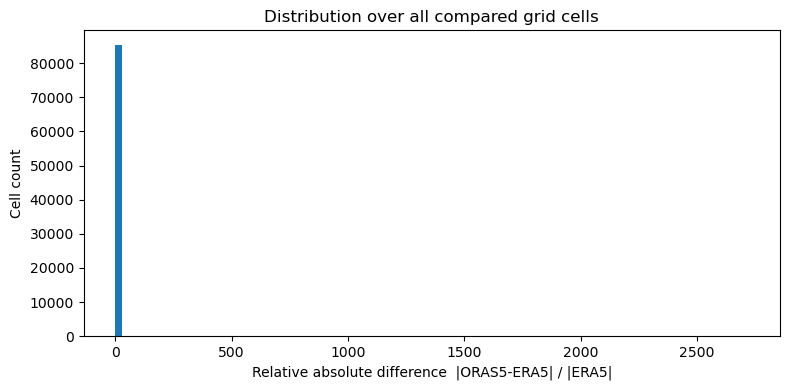

In [22]:
import numpy as np
import matplotlib.pyplot as plt

oras, era = xr.align(sst_oras5_masked, era5_sst_annual, join="exact")

# Only comparing where both are finite
mask = np.isfinite(oras) & np.isfinite(era)

# Relative absolute difference
eps = 1e-12
rel = (np.abs(oras - era) / (np.abs(era) + eps)).where(mask)

# Flatten to 1D for histogram
rel_vals = rel.values.ravel()
rel_vals = rel_vals[np.isfinite(rel_vals)]

N = rel_vals.size
mean_rel = float(rel_vals.mean())
rms_rel  = float(np.sqrt((rel_vals**2).mean()))

print(f"Cells compared (finite in both): N = {N}")
print(f"Mean(relative abs diff) = {mean_rel:.4f}")
print(f"RMS(relative abs diff)  = {rms_rel:.4f}")

plt.figure(figsize=(8,4))
plt.hist(rel_vals, bins=100)
plt.xlabel(r"Relative absolute difference  |ORAS5-ERA5| / |ERA5|")
plt.ylabel("Cell count")
plt.title("Distribution over all compared grid cells")
plt.tight_layout()
plt.show()


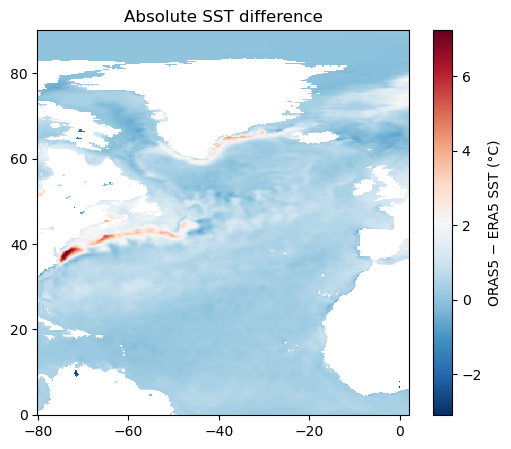

Mean bias (ORAS5 − ERA5): 0.436 °C
RMS difference         : 0.693 °C


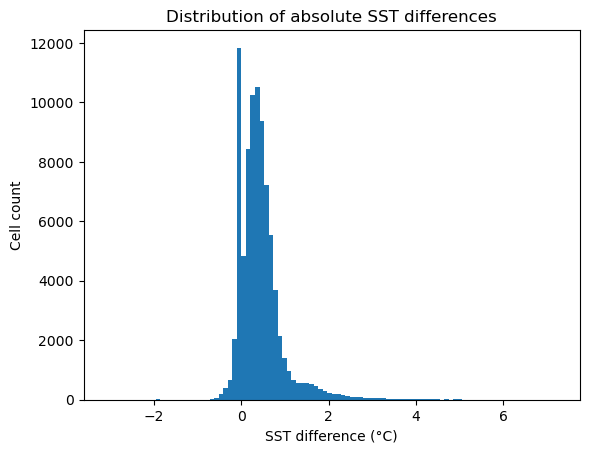

In [23]:
abs_diff = (oras - era).where(mask)

plt.figure(figsize=(6,5))
plt.pcolormesh(abs_diff.longitude, abs_diff.latitude, abs_diff,
               shading="auto", cmap="RdBu_r")
plt.colorbar(label="ORAS5 − ERA5 SST (°C)")
plt.title("Absolute SST difference")
plt.show()

abs_vals = abs_diff.values.ravel()
abs_vals = abs_vals[np.isfinite(abs_vals)]

mean_bias = abs_vals.mean()
rms_diff  = np.sqrt((abs_vals**2).mean())

print(f"Mean bias (ORAS5 − ERA5): {mean_bias:.3f} °C")
print(f"RMS difference         : {rms_diff:.3f} °C")

plt.hist(abs_vals, bins=100)
plt.xlabel("SST difference (°C)")
plt.ylabel("Cell count")
plt.title("Distribution of absolute SST differences")
plt.show()

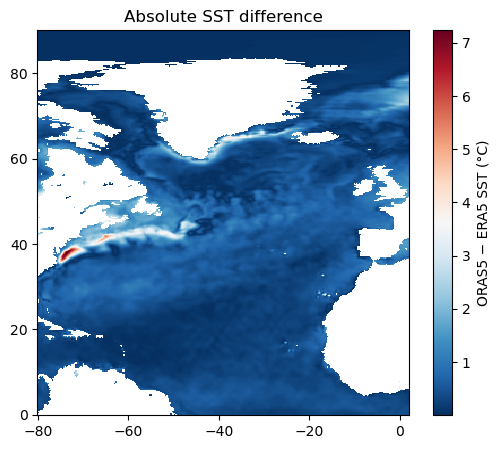

Mean bias (ORAS5 − ERA5): 0.464 °C
RMS difference         : 0.693 °C


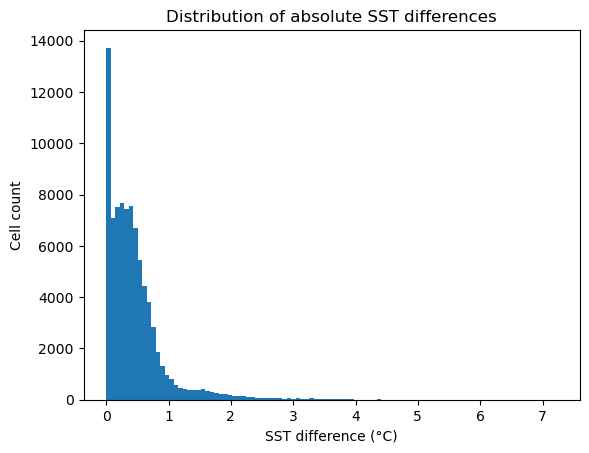

In [24]:
abs_diff = np.absolute((oras - era).where(mask))

plt.figure(figsize=(6,5))
plt.pcolormesh(abs_diff.longitude, abs_diff.latitude, abs_diff,
               shading="auto", cmap="RdBu_r")
plt.colorbar(label="ORAS5 − ERA5 SST (°C)")
plt.title("Absolute SST difference")
plt.show()

abs_vals = abs_diff.values.ravel()
abs_vals = abs_vals[np.isfinite(abs_vals)]

mean_bias = abs_vals.mean()
rms_diff  = np.sqrt((abs_vals**2).mean())

print(f"Mean bias (ORAS5 − ERA5): {mean_bias:.3f} °C")
print(f"RMS difference         : {rms_diff:.3f} °C")

plt.hist(abs_vals, bins=100)
plt.xlabel("SST difference (°C)")
plt.ylabel("Cell count")
plt.title("Distribution of absolute SST differences")
plt.show()

UK cells compared: N = 201
UK mean(rel abs diff) = 0.0829
UK RMS(rel abs diff)  = 0.0839


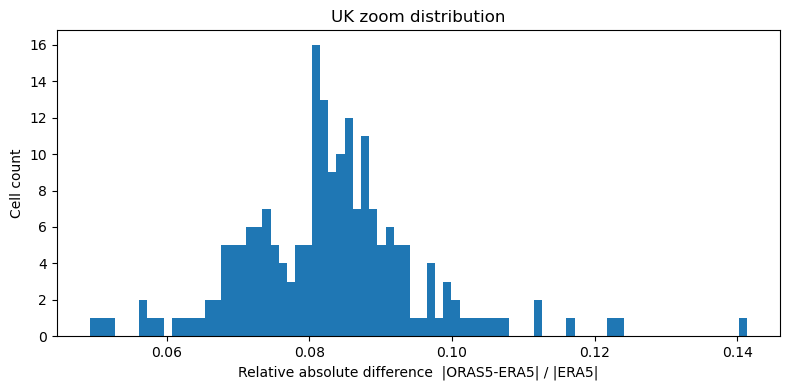

In [25]:
rel_uk = rel.sel(longitude=slice(UK["lon_min"], UK["lon_max"]),
                 latitude=slice(UK["lat_max"], UK["lat_min"]))

rel_uk_vals = rel_uk.values.ravel()
rel_uk_vals = rel_uk_vals[np.isfinite(rel_uk_vals)]

Nuk = rel_uk_vals.size
mean_uk = float(rel_uk_vals.mean())
rms_uk  = float(np.sqrt((rel_uk_vals**2).mean()))

print(f"UK cells compared: N = {Nuk}")
print(f"UK mean(rel abs diff) = {mean_uk:.4f}")
print(f"UK RMS(rel abs diff)  = {rms_uk:.4f}")

plt.figure(figsize=(8,4))
plt.hist(rel_uk_vals, bins=80)
plt.xlabel(r"Relative absolute difference  |ORAS5-ERA5| / |ERA5|")
plt.ylabel("Cell count")
plt.title("UK zoom distribution")
plt.tight_layout()
plt.show()
